In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.maf_proto as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime

from os.path import basename

In [2]:
# Read in the current baseline
db_file = "desi1_v5.2.0_10yrs.db"
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)

In [14]:
note_root = np.array([note.split(",")[0].split(":")[0].split(" ")[0] for note in visits_array["scheduler_note"]])
u_note = np.unique(note_root)

In [15]:
u_note

array(['DD', 'ToO', 'blob_long', 'desi', 'greedy', 'long', 'pair_15',
       'pair_33', 'templates', 'twilight_near_sun'], dtype='<U17')

In [16]:
arrays = []
infos = []

lambs = []
info_lambs= []
for note in u_note:
    indx = np.where(note_root == note)[0]

    info = {"run_name": run_name}
    sub_data = visits_array[indx]
    info['observations_subset'] = note
    sl = maf.Slicer()
    metric = maf.CountMetric()
    #metric = maf.CountMetric()
    # Run the metics through the slicer
    hp_array, info = sl(sub_data, metric, info=info)
    arrays.append(hp_array)
    infos.append(info)

    info = {"run_name": run_name}
    info['observations_subset'] = note
    sl = maf.Slicer(lon_col="azimuth", lat_col="altitude", nside=64)
    metric = maf.CountMetric()
    hp_array, info = sl(sub_data, metric, info=info)
    lambs.append(hp_array)
    info_lambs.append(info)


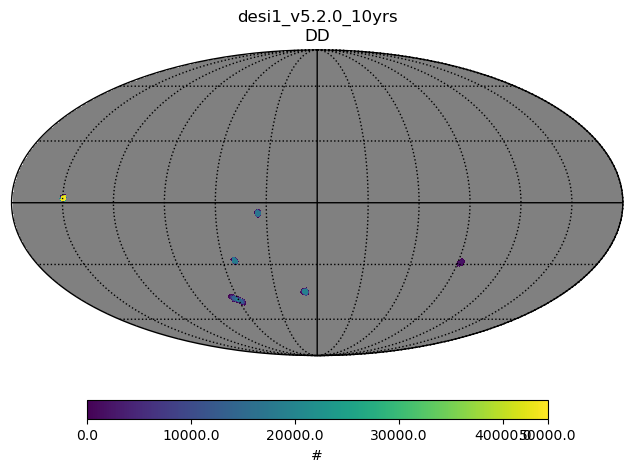

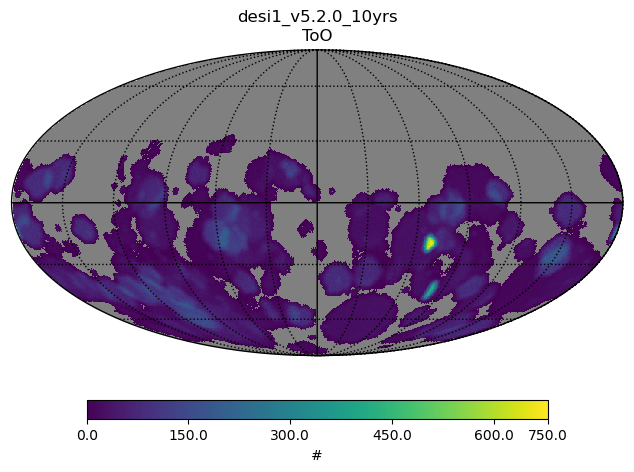

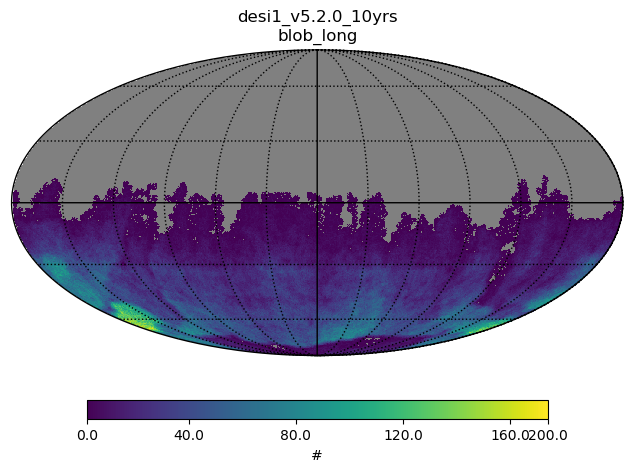

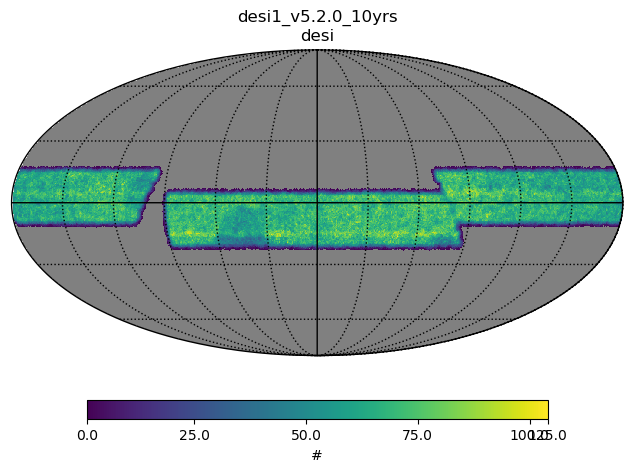

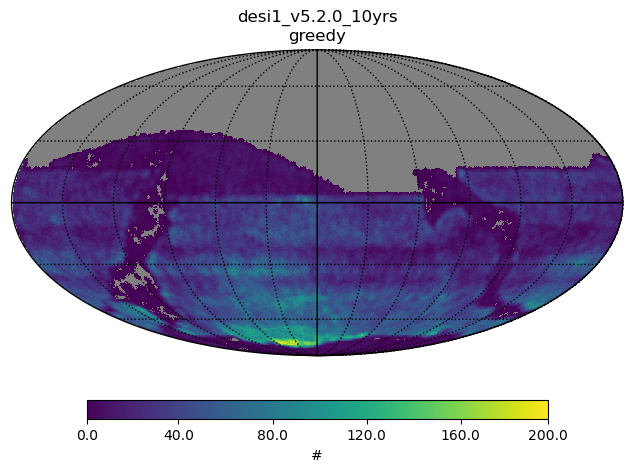

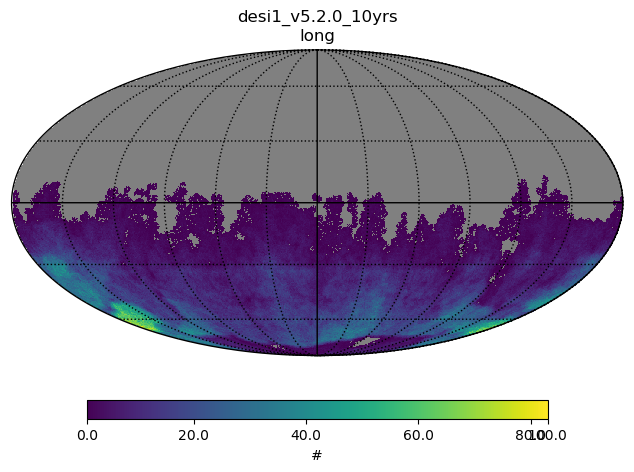

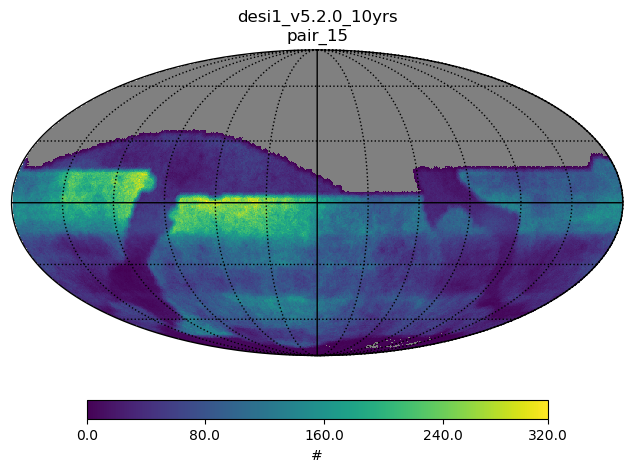

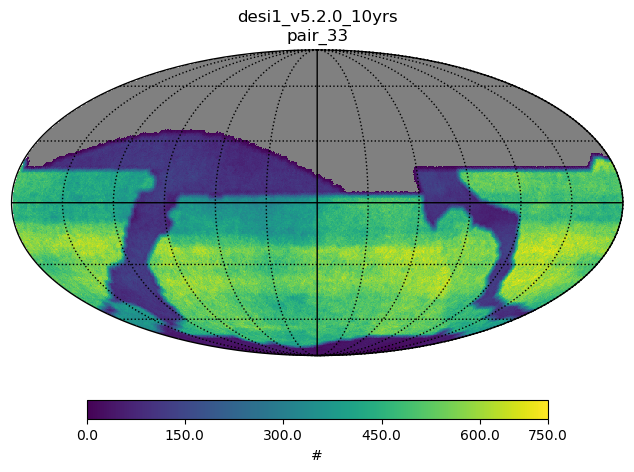

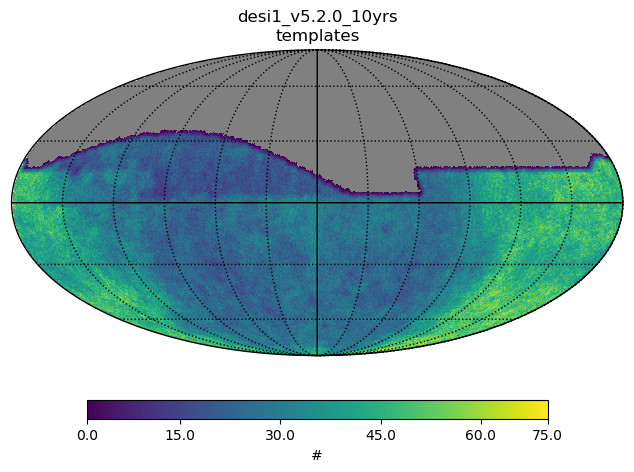

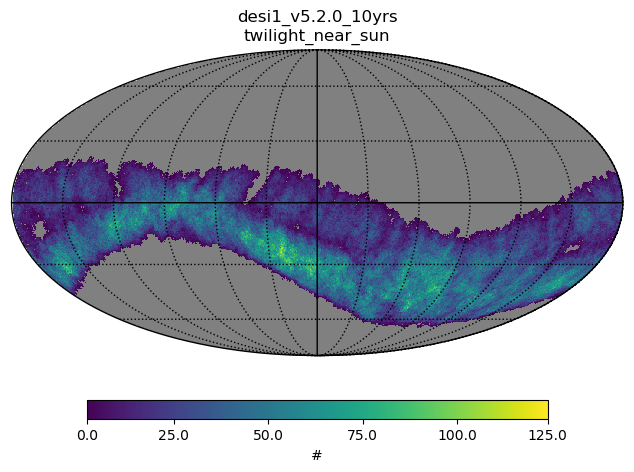

In [17]:
for hp_array,info in zip(arrays, infos):
    pm = maf.PlotMoll(info=info)
    fig = pm(hp_array)

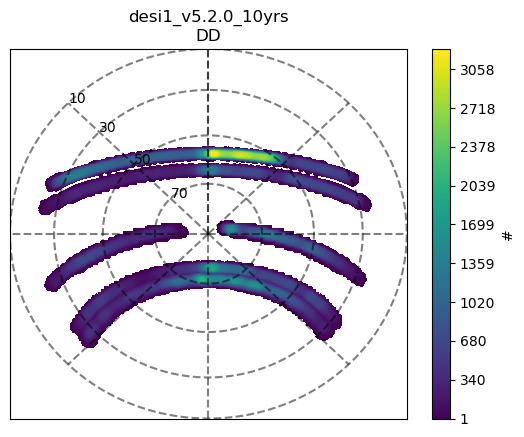

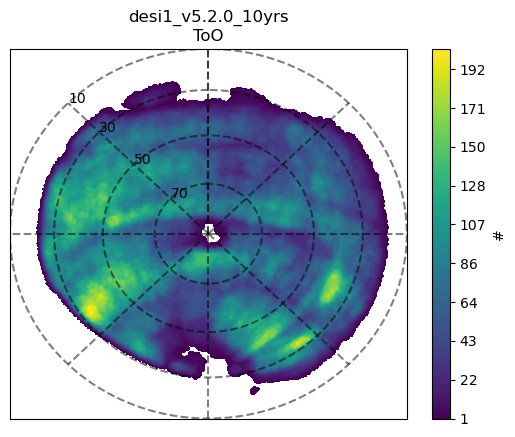

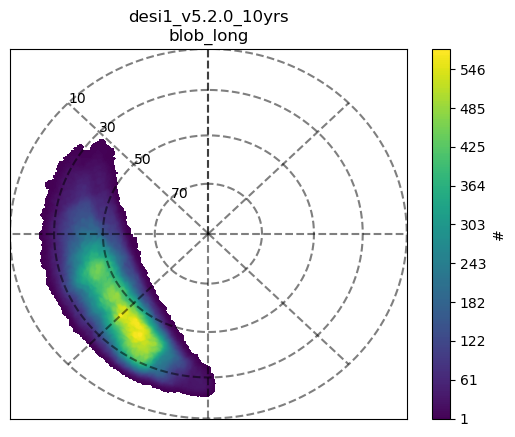

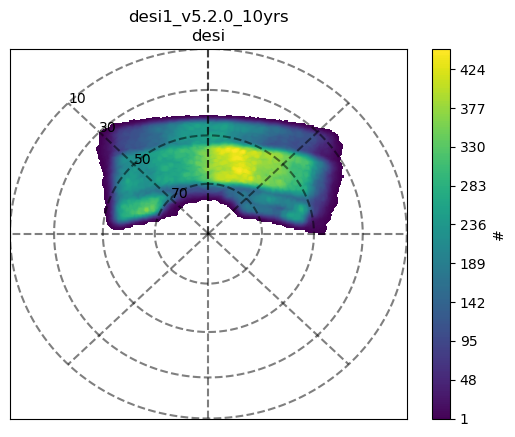

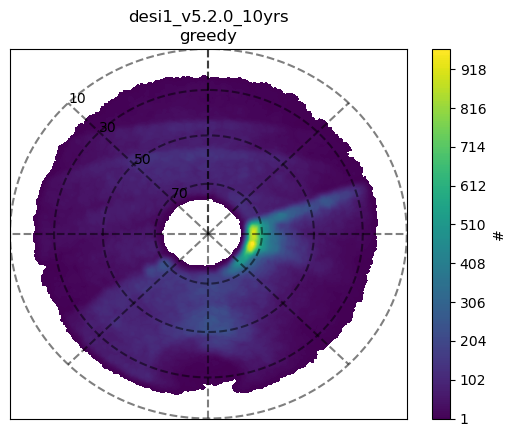

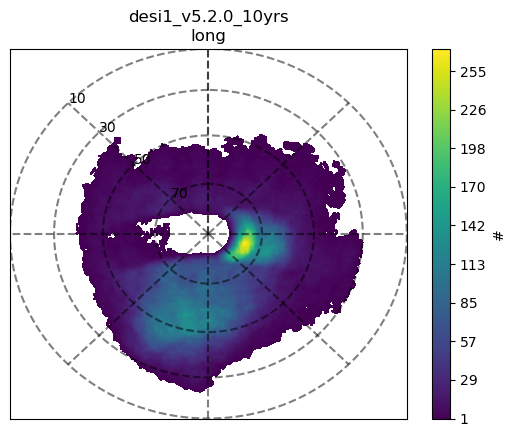

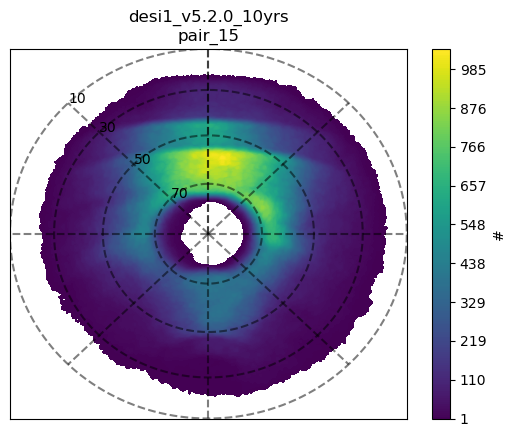

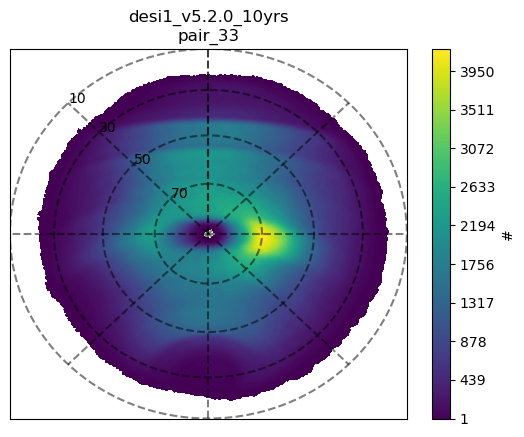

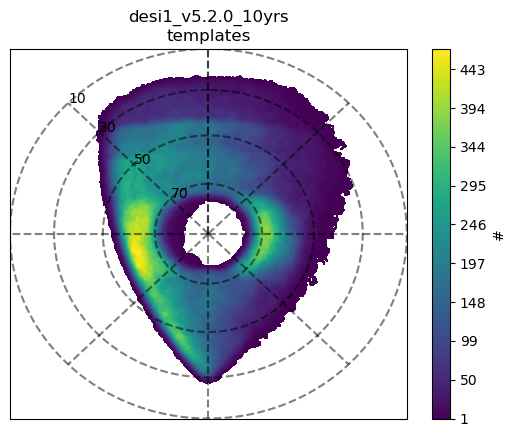

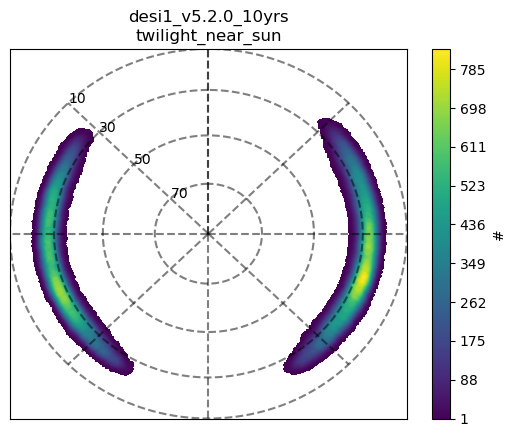

In [18]:
for hp_array,info in zip(lambs, info_lambs):
    pm = maf.PlotLambert(info=info)
    fig = pm(hp_array)